<a href="https://colab.research.google.com/github/Jhairg9/CI345/blob/main/Homework_2_by_Jhair_Morales_Gonzalez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Homework 2
##Jhair Morales Gonzalez
05/18/26

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Step 1: Loading and Analyze

# Step 2: Basic Analysis

In [39]:
df = pd.read_csv('/content/drive/MyDrive/CI345_ML/data/diabetes_prediction_dataset.csv')
df.head(2)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0


In [40]:
df.shape

(100000, 9)

In [41]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [42]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [43]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [44]:
df[['age','bmi']].describe()

,age,bmi
count,100000.000000,100000.000000
mean,41.885856,27.320767
std,22.516840,6.636783
min,0.080000,10.010000
25%,24.000000,23.630000
50%,43.000000,27.320000
75%,60.000000,29.580000
max,80.000000,95.690000


In [45]:
print("Mean:")
print(df[['age', 'bmi']].mean())

print("\nStandard Deviation:")
print(df[['age', 'bmi']].std())

print("\nMinimum:")
print(df[['age', 'bmi']].min())

print("\nMaximum:")
print(df[['age', 'bmi']].max())

Mean:
age    41.885856
bmi    27.320767
dtype: float64

Standard Deviation:
age    22.516840
bmi     6.636783
dtype: float64

Minimum:
age     0.08
bmi    10.01
dtype: float64

Maximum:
age    80.00
bmi    95.69
dtype: float64


#Step 3: Data Visualization

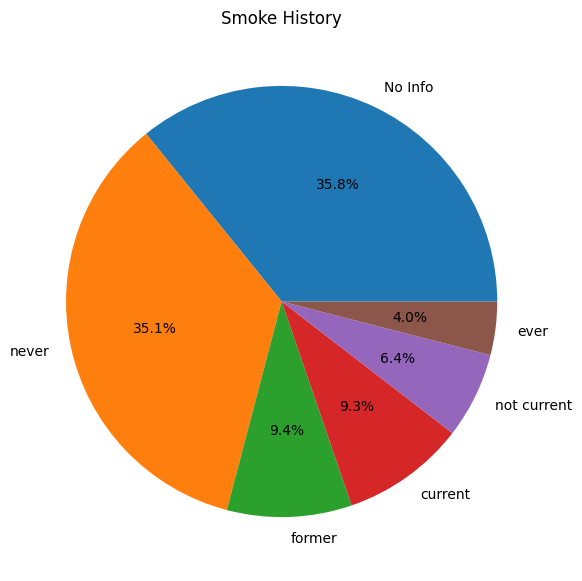

In [47]:
smoke_counts = df['smoking_history'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    smoke_counts, labels=smoke_counts.index, autopct='%1.1f%%'
)
plt.title('Smoke History')
plt.show()

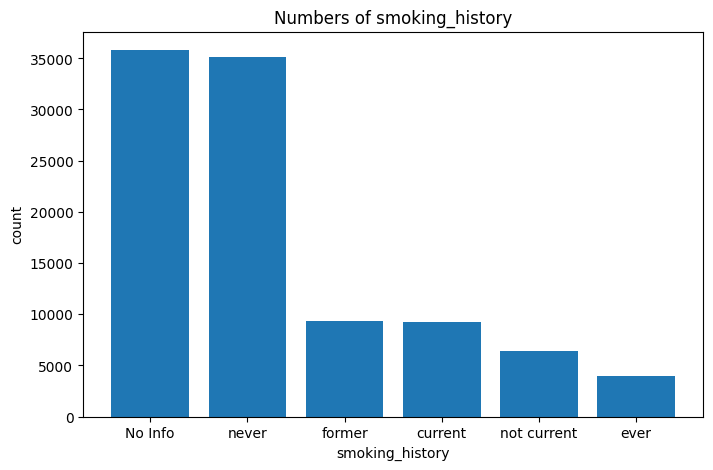

In [48]:
smoke_counts = df['smoking_history'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(smoke_counts.index, smoke_counts.values)
plt.title('Numbers of smoking_history')
plt.xlabel('smoking_history')
plt.ylabel('count')

plt.show()

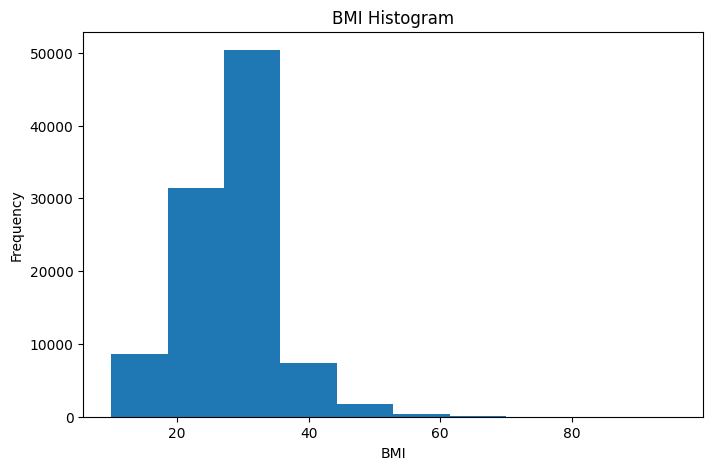

In [49]:
plt.figure(figsize=(8,5))
plt.hist(df['bmi'], bins=10)
plt.title('BMI Histogram')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.show()

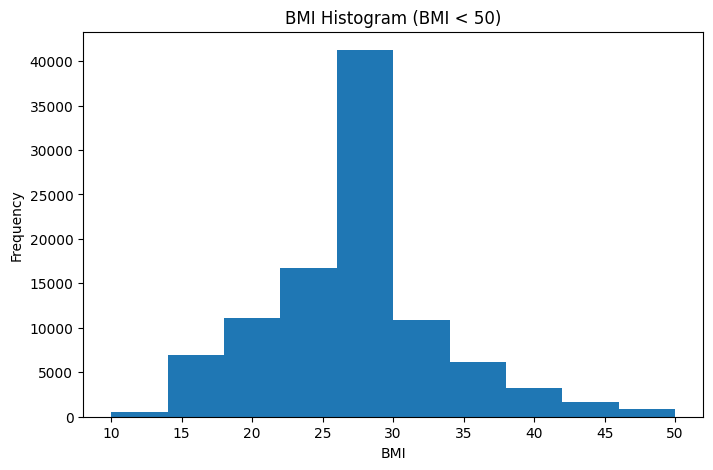

In [ ]:
bmi_under_50 = df[df['bmi'] < 50]
plt.figure(figsize=(8,5))
plt.hist(bmi_under_50['bmi'], bins=10)

plt.title('BMI Histogram (BMI < 50)')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.show()

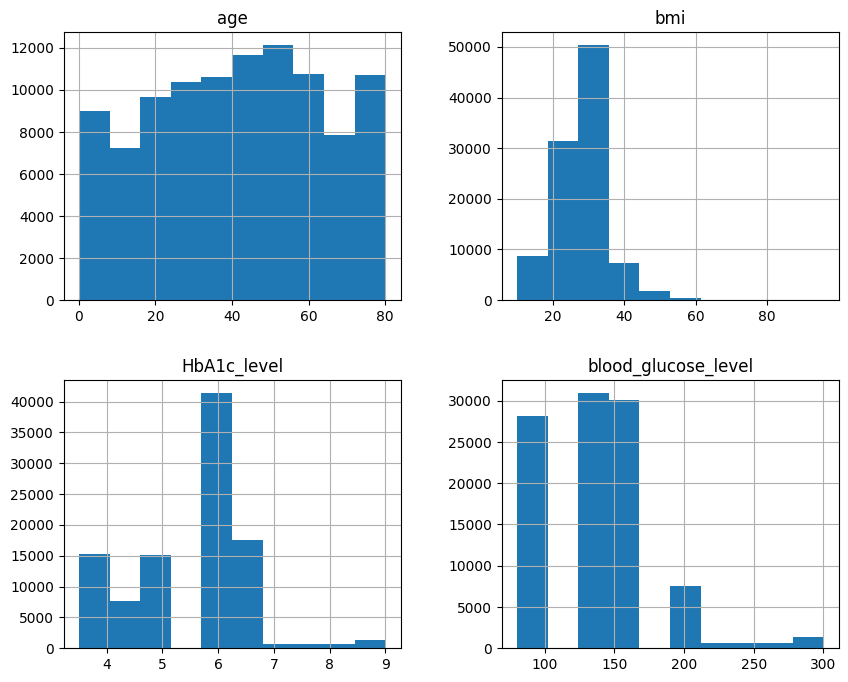

In [50]:
df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']].hist(figsize=(10,8))

plt.show()

diabetes
0    91500
1     8500
Name: count, dtype: int64


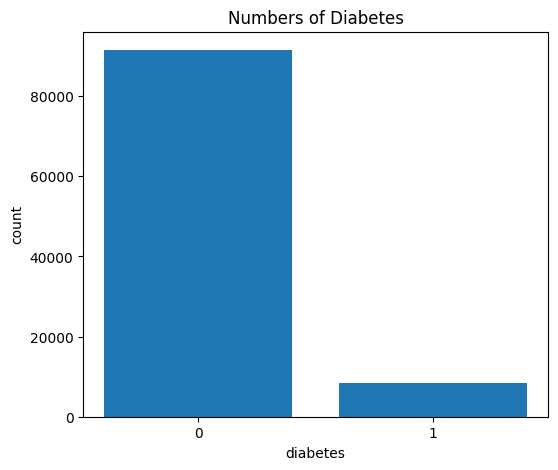

In [60]:
diabetes_counts = df['diabetes'].value_counts()
print(diabetes_counts)
plt.figure(figsize=(6,5))
plt.bar(diabetes_counts.index.astype(str), diabetes_counts.values)

plt.title('Numbers of Diabetes')
plt.xlabel('diabetes')
plt.ylabel('count')

plt.show()

# Step 4: Data Processing

In [61]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
print(df['gender'].dtypes)
df.head(2)

int64


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_hist
0,0,80.0,0,1,never,25.19,6.6,140,0,0
1,0,54.0,0,0,No Info,27.32,6.6,80,0,2


In [62]:
hist_map = {
    'never': 0,
    'No Info': 2,
    'current': 10,
    'former': 8,
    'ever': 20,
    'not current': 5
}
df['smoking_hist'] = df['smoking_history'].map(hist_map)
df.head(2)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_hist
0,0,80.0,0,1,never,25.19,6.6,140,0,0
1,0,54.0,0,0,No Info,27.32,6.6,80,0,2


In [57]:
category_cols = ['gender', 'smoking_history']
df_use_dummies = pd.get_dummies(df, columns=category_cols, dtype=int)
print(df_use_dummies.dtypes)
df_use_dummies.head(2)

age                            float64
hypertension                     int64
heart_disease                    int64
bmi                            float64
HbA1c_level                    float64
blood_glucose_level              int64
diabetes                         int64
smoking_hist                     int64
gender_0                         int64
gender_1                         int64
gender_2                         int64
smoking_history_No Info          int64
smoking_history_current          int64
smoking_history_ever             int64
smoking_history_former           int64
smoking_history_never            int64
smoking_history_not current      int64
dtype: object


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_hist,gender_0,gender_1,gender_2,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,2,1,0,0,1,0,0,0,0,0


In [63]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
encoded = ohe.fit_transform(df[['gender']])
encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=ohe.get_feature_names_out(['gender'])
)
encoded_df.head()

,gender_0,gender_1,gender_2
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,0.0,1.0,0.0


#Step 5: Separate Data feature and target

In [64]:
cols_used = [
    'gender',
    'age',
    'smoking_hist'
]
data = df[cols_used]
target = df['diabetes']
print(data.shape)
print(target.shape)
data.head()

(100000, 3)
(100000,)


,gender,age,smoking_hist
0,0,80.0,0
1,0,54.0,2
2,1,28.0,0
3,0,36.0,10
4,1,76.0,10


#Step 6 Training 3 classifiers

In [66]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data,
    target,
    test_size=0.5,
    random_state=42
)

print(data_train.shape)
print(data_test.shape)

(50000, 3)
(50000, 3)


In [68]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

for k in [3, 5, 7]:

    print(f"\nKNN with k = {k}")

    knn = KNeighborsClassifier(n_neighbors=25)

    knn.fit(data_train, target_train)

    predicted = knn.predict(data_test)

    print(classification_report(target_test, predicted))

    print("Confusion Matrix:")
    print(confusion_matrix(target_test, predicted))


KNN with k = 3


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.91      1.00      0.96     45741
           1       0.00      0.00      0.00      4259

    accuracy                           0.91     50000
   macro avg       0.46      0.50      0.48     50000
weighted avg       0.84      0.91      0.87     50000

Confusion Matrix:
[[45741     0]
 [ 4259     0]]

KNN with k = 5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.91      1.00      0.96     45741
           1       0.00      0.00      0.00      4259

    accuracy                           0.91     50000
   macro avg       0.46      0.50      0.48     50000
weighted avg       0.84      0.91      0.87     50000

Confusion Matrix:
[[45741     0]
 [ 4259     0]]

KNN with k = 7
              precision    recall  f1-score   support

           0       0.91      1.00      0.96     45741
           1       0.00      0.00      0.00      4259

    accuracy                           0.91     50000
   macro avg       0.46      0.50      0.48     50000
weighted avg       0.84      0.91      0.87     50000

Confusion Matrix:
[[45741     0]
 [ 4259     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
